1. Initialisation du modèle...
2. Simulation en cours (SDE + Jumps)...
3. Génération du graphique...


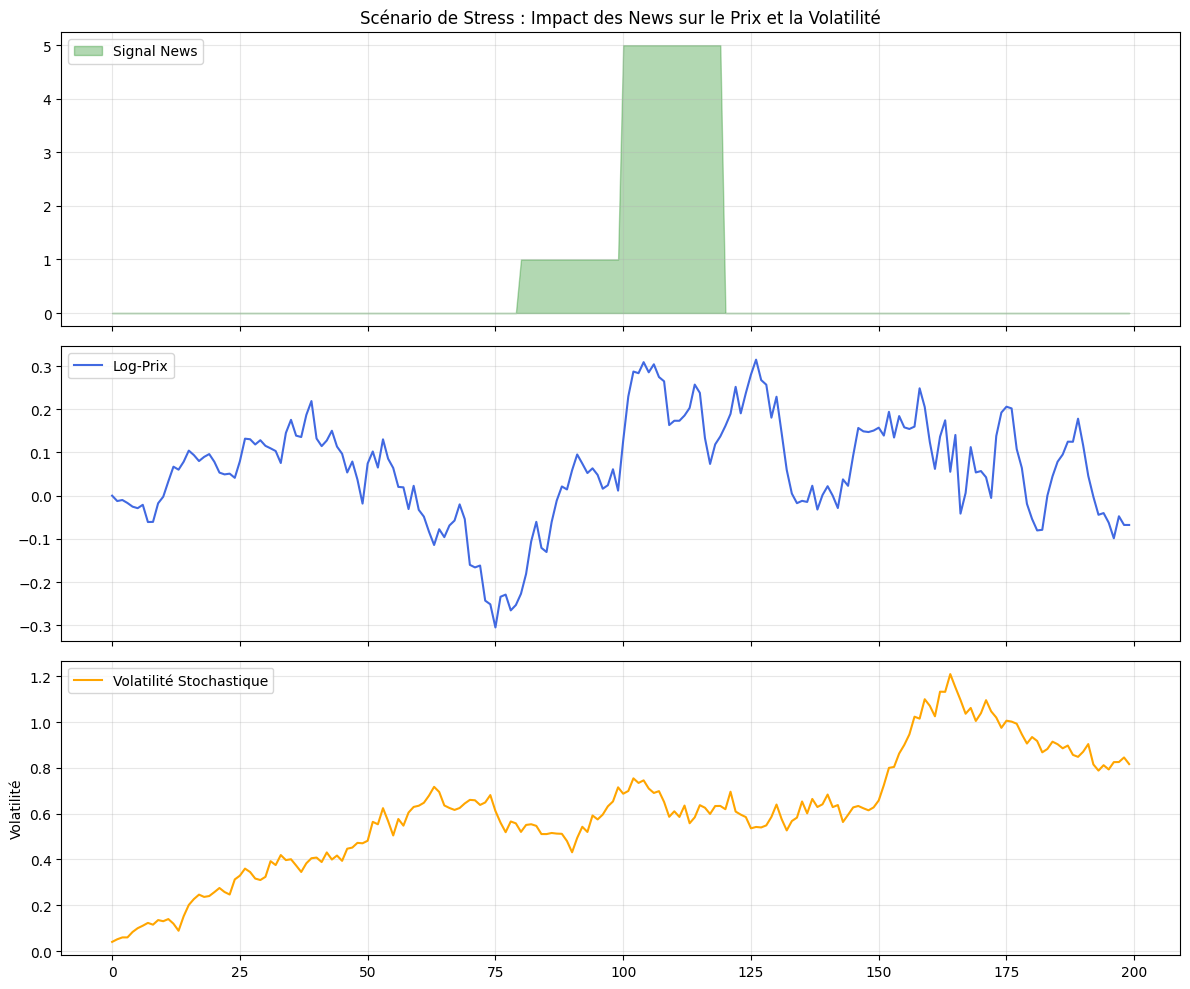

4. Terminé.


In [1]:
# --- COMMANDE MAGIQUE POUR FORCER L'AFFICHAGE ---
%matplotlib inline 
import matplotlib.pyplot as plt
import torch
import sys
import os

# Astuce imports
module_path = os.path.abspath(os.path.join('..', 'src'))
if module_path not in sys.path:
    sys.path.append(module_path)

from neural_quant.models.hybrid import HybridJumpDiffusion

def run_stress_test():
    print("1. Initialisation du modèle...")
    input_dim = 1
    hidden_dim = 32
    T_days = 200
    dt = 1.0 / 252.0
    
    model = HybridJumpDiffusion(input_dim=input_dim, hidden_dim=hidden_dim)
    
    # Scénario
    z_signal = torch.zeros(T_days, 1, input_dim)
    z_signal[80:100] = 1.0  
    z_signal[100:120] = 5.0 
    
    print("2. Simulation en cours (SDE + Jumps)...")
    with torch.no_grad():
        prices, vols, jumps = model.forward_simulation(z_signal, dt=dt)
        
    prices = prices[:, 0].numpy()
    vols = vols[:, 0].numpy()
    jumps = jumps[:, 0].numpy()
    signal = z_signal[:, 0, 0].numpy()
    
    print("3. Génération du graphique...")
    
    # Création de la figure
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    # Panel 1
    ax1.fill_between(range(T_days), signal, color='green', alpha=0.3, label='Signal News')
    ax1.set_title('Scénario de Stress : Impact des News sur le Prix et la Volatilité')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Panel 2
    ax2.plot(prices, color='royalblue', linewidth=1.5, label='Log-Prix')
    jump_indices = [i for i, x in enumerate(jumps) if x > 0]
    if jump_indices:
        ax2.vlines(jump_indices, min(prices), max(prices), colors='red', linestyles='dashed', alpha=0.5, label='Sauts')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    # Panel 3
    ax3.plot(vols, color='orange', label='Volatilité Stochastique')
    ax3.set_ylabel('Volatilité')
    ax3.legend(loc='upper left')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # L'ORDRE EXPLICTE D'AFFICHAGE
    plt.show()
    print("4. Terminé.")

# --- APPEL DIRECT DE LA FONCTION (Sans if __name__) ---
run_stress_test()